# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmedali3ff/Flyrank-internship-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
from pathlib import Path

REPO_PATH = Path("/content/Flyrank-internship-")
print("Repository path:", REPO_PATH)
print("Exists:", REPO_PATH.exists())

Repository path: /content/Flyrank-internship-
Exists: True


In [2]:
import pandas as pd
from pathlib import Path

# Find the dataset inside the cloned repository
matches = list(Path("/content").rglob("content_refresh_anonymized.csv"))

if not matches:
    raise FileNotFoundError(
            "Dataset not found. Make sure the FlyRank repository is available in Colab."
                )

data_path = matches[0]
print("Dataset:", data_path)

                # Load data
df = pd.read_csv(data_path)

                # Create the target label
df["is_declining_label"] = (
df["trend_direction"].astype(str).str.lower() == "down"
                    ).astype(int)

                    # Basic checks
print("\nDataset shape:", df.shape)
print("Declining rate:", round(df["is_declining_label"].mean(), 4))

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts().sort_index())

Dataset: /content/Flyrank-internship-/data/raw/content_refresh_anonymized.csv

Dataset shape: (30000, 45)
Declining rate: 0.5421

Target distribution:
is_declining_label
0    13738
1    16262
Name: count, dtype: int64


In [3]:
# Features used by the model
feature_cols = [
    "search_volume",
        "competition",
            "cpc",
                "word_count",
                    "char_count",
                        "impressions_90d",
                            "clicks_90d",
                                "pageviews_90d",
                                    "sessions_90d",
                                        "users_90d",
                                            "engaged_sessions_90d",
                                                "ai_sessions_90d",
                                                    "scroll_events_90d",
                                                        "days_with_impressions",
                                                            "days_with_sessions",
                                                                "impressions_last_30d",
                                                                    "clicks_last_30d",
                                                                        "sessions_last_30d",
                                                                            "impressions_prev_30d",
                                                                                "clicks_prev_30d",
                                                                                    "sessions_prev_30d",
                                                                                        "content_age_days",
                                                                                            "days_since_last_update",
                                                                                                "ctr",
                                                                                                    "avg_position",
                                                                                                        "engagement_rate",
                                                                                                            "scroll_rate",
                                                                                                                "ai_traffic_pct"
                                                                                                                ]

                                                                                                                # Target
target_col = "is_declining_label"

                                                                                                                # Columns deliberately excluded to prevent target leakage
excluded_cols = [
                                                                                                                    "trend_direction",
                                                                                                                        "trend_pct"
                                                                                                                        ]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nExcluded leakage-prone columns:")
for col in excluded_cols:
                                                                                                                            print("-", col)

                                                                                                                            print("\nMissing values in features:", X.isna().sum().sum())

Number of features: 28
X shape: (30000, 28)
y shape: (30000,)

Excluded leakage-prone columns:
- trend_direction

Missing values in features: 22927
- trend_pct

Missing values in features: 22927


In [4]:
# Inspect feature data types and missing values

print("Feature data types:")
print(X.dtypes.value_counts())

print("\nTop features by missing-value count:")
missing_summary = (
    X.isna()
        .sum()
            .sort_values(ascending=False)
            )

print(missing_summary.head(10))

print("\nTarget missing values:", y.isna().sum())

Feature data types:
int64      18
float64    10
Name: count, dtype: int64

Top features by missing-value count:
word_count         7699
char_count         7699
competition        2468
search_volume      2468
cpc                2468
scroll_rate         125
clicks_90d            0
impressions_90d       0
sessions_90d          0
users_90d             0
dtype: int64

Target missing values: 0


In [5]:
from sklearn.model_selection import GroupShuffleSplit

# Grouped train/test split
# This prevents the same client from appearing in both sets.
groups = df["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
        test_size=0.20,
            random_state=42
            )

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())
print("\nClient overlap:",
                  len(set(groups_train) & set(groups_test)))

print("\nTrain declining rate:", round(y_train.mean(), 4))
print("Test declining rate:", round(y_test.mean(), 4))

Train shape: (23837, 28)
Test shape: (6163, 28)

Train clients: 25
Test clients: 7

Client overlap: 0

Train declining rate: 0.5501
Test declining rate: 0.511


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
        precision_score,
            recall_score,
                f1_score,
                    roc_auc_score
                    )

                    # Majority-class baseline
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

baseline_metrics = {
                        "Accuracy": accuracy_score(y_test, baseline_pred),
                            "Precision": precision_score(y_test, baseline_pred, zero_division=0),
                                "Recall": recall_score(y_test, baseline_pred, zero_division=0),
                                    "F1": f1_score(y_test, baseline_pred, zero_division=0),
                                        "ROC-AUC": roc_auc_score(y_test, baseline_prob)
                                        }

print("Majority Baseline Results:")
for metric, value in baseline_metrics.items():
                                            print(f"{metric}: {value:.4f}")

Majority Baseline Results:
Accuracy: 0.5110
Precision: 0.5110
Recall: 1.0000
F1: 0.6763
ROC-AUC: 0.5000


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Build the modeling pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                    max_iter=1000,
                            random_state=42
                                ))
                                ])

                                # Train only on the training set

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [8]:
# Generate predictions on the unseen test set

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Predicted classes:", len(y_pred))
print("Predicted probabilities:", len(y_prob))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 probabilities:")
print(y_prob[:10])

Predictions generated successfully.
Predicted classes: 6163
Predicted probabilities: 6163

First 10 predictions:
[1 1 1 1 1 1 1 0 1 0]

First 10 probabilities:
[0.93037261 0.99999908 0.91592963 0.58377295 0.64063749 0.92586467
 0.80569898 0.33959766 0.50267278 0.46653781]


In [9]:
from sklearn.metrics import (
      accuracy_score,
          precision_score,
              recall_score,
                  f1_score,
                      roc_auc_score
                      )
model_metrics = {
                          "Accuracy": accuracy_score(y_test, y_pred),
                              "Precision": precision_score(y_test, y_pred, zero_division=0),
                                  "Recall": recall_score(y_test, y_pred, zero_division=0),
                                      "F1": f1_score(y_test, y_pred, zero_division=0),
                                          "ROC-AUC": roc_auc_score(y_test, y_prob)
                                          }

print("Logistic Regression Results:")
for metric, value in model_metrics.items():
                                              print(f"{metric}: {value:.4f}")


Logistic Regression Results:
Accuracy: 0.7561
Precision: 0.8071
Recall: 0.6869
F1: 0.7422
ROC-AUC: 0.8497


In [10]:
comparison = pd.DataFrame({
      "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
          "Majority Baseline": [
                  baseline_metrics["Accuracy"],
                          baseline_metrics["Precision"],
                                  baseline_metrics["Recall"],
                                          baseline_metrics["F1"],
                                                  baseline_metrics["ROC-AUC"]
                                                      ],
                                                          "Logistic Regression": [
                                                                  model_metrics["Accuracy"],
                                                                          model_metrics["Precision"],
                                                                                  model_metrics["Recall"],
                                                                                          model_metrics["F1"],
                                                                                                  model_metrics["ROC-AUC"]
                                                                                                      ]
                                                                                                      })
comparison["Improvement"] = (
                                                                                                          comparison["Logistic Regression"]
                                                                                                              - comparison["Majority Baseline"]
                                                                                                              )

print(comparison.to_string(index=False))


   Metric  Majority Baseline  Logistic Regression  Improvement
 Accuracy           0.510952             0.756125     0.245173
Precision           0.510952             0.807090     0.296137
   Recall           1.000000             0.686885    -0.313115
       F1           0.676332             0.742151     0.065820
  ROC-AUC           0.500000             0.849691     0.349691


In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nDetailed counts:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

Confusion Matrix:
[[2497  517]
 [ 986 2163]]

Detailed counts:
True Negatives (TN):  2497
False Positives (FP): 517
False Negatives (FN): 986
True Positives (TP):  2163


In [12]:
# Compare random-split and client-grouped validation

random_split_metrics = {
    "Accuracy": 0.8218,
        "Precision": 0.8429,
            "Recall": 0.8250,
                "F1": 0.8339,
                    "ROC-AUC": 0.9124
                    }

grouped_split_metrics = model_metrics
print("Random Split vs Grouped Split")
print("-" * 50)

for metric in random_split_metrics:
                        random_value = random_split_metrics[metric]
grouped_value = grouped_split_metrics[metric]
difference = random_value - grouped_value
print(
                                            f"{metric:10s} | "
                                                    f"Random: {random_value:.4f} | "
                                                            f"Grouped: {grouped_value:.4f} | "
                                                                    f"Difference: {difference:.4f}"
                                                                        )

Random Split vs Grouped Split
--------------------------------------------------
ROC-AUC    | Random: 0.9124 | Grouped: 0.8497 | Difference: 0.0627


In [13]:
# Inspect Logistic Regression coefficients

classifier = model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "Feature": feature_cols,
        "Coefficient": classifier.coef_[0]
        })

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
            "Absolute_Coefficient",
                ascending=False
                )

print("Top 10 features by absolute coefficient:")
print(
                    coefficients[
                            ["Feature", "Coefficient"]
                                ].head(10).to_string(index=False)
                                )

Top 10 features by absolute coefficient:
              Feature  Coefficient
 impressions_last_30d   -35.300676
 impressions_prev_30d    29.286873
      impressions_90d     1.502555
      clicks_last_30d    -0.877940
      clicks_prev_30d     0.802428
    sessions_last_30d    -0.795042
         sessions_90d     0.732098
        pageviews_90d     0.720186
            users_90d    -0.691704
days_with_impressions     0.545294


In [14]:
from pathlib import Path

# Save coefficient analysis as a reproducible artifact
output_dir = Path("/content/Flyrank-internship-/work/artifacts")
output_dir.mkdir(parents=True, exist_ok=True)

coefficients.to_csv(
    output_dir / "logistic_regression_coefficients.csv",
        index=False
        )

print("Saved:")
print(output_dir / "logistic_regression_coefficients.csv")

Saved:
/content/Flyrank-internship-/work/artifacts/logistic_regression_coefficients.csv


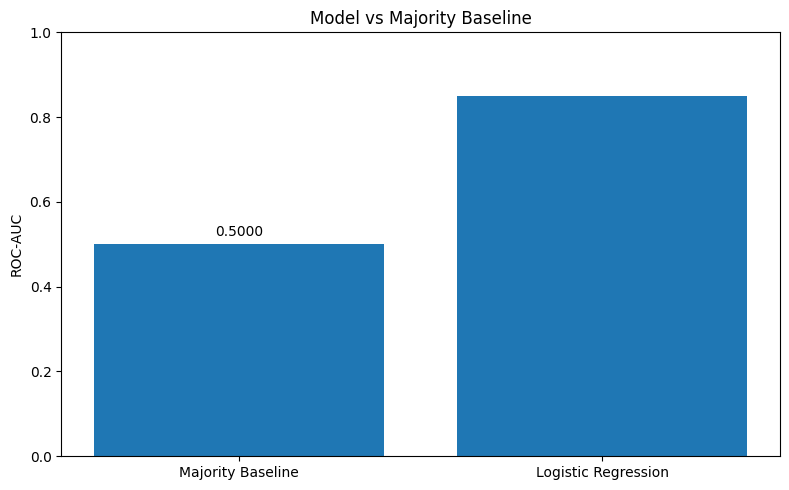

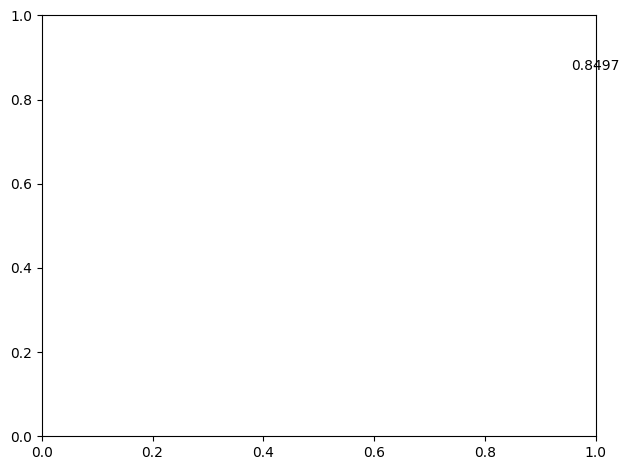

In [15]:
import matplotlib.pyplot as plt

models = ["Majority Baseline", "Logistic Regression"]
roc_auc_values = [
    baseline_metrics["ROC-AUC"],
        model_metrics["ROC-AUC"]
        ]

plt.figure(figsize=(8, 5))
plt.bar(models, roc_auc_values)
plt.ylabel("ROC-AUC")
plt.title("Model vs Majority Baseline")
plt.ylim(0, 1)

for i, value in enumerate(roc_auc_values):
            plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

            plt.tight_layout()
            plt.show()

## 1. Question
## 1. Research Question

### Question

Can historical search, traffic, engagement, and content-freshness signals identify content that is currently showing a declining trend?

### Decision Context

The goal is not to automate content decisions. The goal is to provide a measurable, reproducible signal that can help prioritize which content should be reviewed first.

## 2. Data

This analysis uses the FlyRank ML Internship dataset available in the repository.

The working dataset contains **30,000 observations and 44 original columns**. A binary target is created from `trend_direction`, where observations with a value of `down` are labeled as declining.

The target column is created only after loading the source data and is not used as a model feature.

## 3. Methodology

### 3.1 Target Definition

The task is framed as binary classification.

- `1` = declining content
- `0` = non-declining content

The label is derived from `trend_direction`.

### 3.2 Feature Selection

The model uses 28 search, traffic, engagement, and content-freshness features.

Two columns are deliberately excluded:

- `trend_direction` — directly used to construct the target.
- `trend_pct` — directly describes the underlying trend and could leak outcome information.

### 3.3 Validation Design

A client-grouped train/test split is used to reduce the risk of evaluating the model on observations from the same client in both sets.

- Train: 23,837 observations
- Test: 6,163 observations
- Train clients: 25
- Test clients: 7
- Client overlap: 0

This grouped evaluation is treated as the primary result.

## 4. Results

The primary evaluation uses the client-grouped test split described above.

The Logistic Regression model is compared against a majority-class baseline on the **same test set**, so the comparison reflects the value added by the model rather than differences in evaluation data.

### Primary Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Majority baseline | 51.10% | 51.10% | 100.00% | 67.63% | 0.5000 |
| Logistic Regression | 75.61% | 80.71% | 68.69% | 74.22% | 0.8497 |

The model substantially improves discrimination over the majority baseline, with a ROC-AUC of **0.8497** compared with **0.5000** for the baseline.

However, recall is lower than the baseline because the baseline predicts every observation as declining. Therefore, the model should be interpreted as a prioritization tool rather than a system intended to capture every declining observation.

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Research Question
Can historical search, traffic, engagement, and content-freshness signals identify content that is currently showing a declining trend?

### 0:45–1:30 — Data
The dataset contains 30,000 observations and 44 original columns. The target labels observations as declining when `trend_direction` is `down`.

### 1:30–2:30 — Methodology
I excluded `trend_direction` and `trend_pct` to avoid target leakage. I used a client-grouped train/test split with zero client overlap, median imputation, standardization, and Logistic Regression.

### 2:30–3:30 — Results
The grouped test set produced ROC-AUC of 0.8497, accuracy of 75.61%, precision of 80.71%, recall of 68.69%, and F1 of 74.22%, compared with a majority-class ROC-AUC of 0.5000.

### 3:30–4:15 — What Changed
A random split produced ROC-AUC of 0.9124, while the grouped split produced 0.8497. This shows why validation by client matters for estimating generalization.

### 4:15–5:00 — Decision Use
The model should be used as decision-support for prioritizing content review, not as an autonomous decision-maker. The main limitation is that the data is observational and recent-performance signals may be closely related to the outcome.

## ML-12 — Social Post Cut

I built a content-decline classifier using historical search, traffic, engagement, and freshness signals.

On a client-grouped test set, Logistic Regression reached **0.8497 ROC-AUC**, **75.61% accuracy**, and **74.22% F1**, outperforming a majority-class baseline with **0.5000 ROC-AUC**.

One important finding: random splitting gave a higher ROC-AUC of **0.9124**, showing why grouping by client matters when estimating how well the model generalizes.

The model is designed for **decision-support and content-review prioritization**, not autonomous decisions.

## ML-12 — Employer-Facing Summary

I developed and evaluated a leakage-aware Logistic Regression model to identify content observations showing a declining trend using historical search, traffic, engagement, and freshness signals.

Using client-grouped validation with zero client overlap, the model achieved **0.8497 ROC-AUC**, **75.61% accuracy**, and **74.22% F1**, while outperforming a majority-class baseline.

The project demonstrates practical ML workflow skills including target definition, leakage checks, grouped validation, baseline comparison, model evaluation, error analysis, and translating model outputs into decision-support recommendations.